In [26]:
# =============================================================================
# NOTEBOOK SETUP - Two Population Delay Sweep Execution
# =============================================================================
import os
import sys
from pathlib import Path
from brian2 import *


# Robust directory setup
if Path.cwd().name == 'old_notebooks':
    os.chdir("../../../")

print(os.getcwd())
from src.two_populations.helpers.logger import setup_logger

logger = setup_logger(
    experiment_name="test_delays",
    console_level="DEBUG",
    log_to_file=False
)

restore_initial_state()

logger.info(f"Working directory: {Path.cwd()}")
logger.info(f"Python path: {sys.path[0]}")

INFO     | __main__:<module>:25 - Working directory: /home/tonicoll/Projects/izhikevich
INFO     | __main__:<module>:26 - Python path: /home/tonicoll/.conda/envs/neurophysics/lib/python311.zip


/home/tonicoll/Projects/izhikevich


In [27]:
from src.two_populations.model import IzhikevichNetwork
import numpy as np
from src.two_populations.metrics import analyze_simulation_results, print_network_statistics_table
from src.two_populations.plots.dashboard_plots import plot_connectivity_dashboard, plot_population_dashboard
from loguru import logger

# =============================================================================
# SINGLE SIMULATION CONFIGURATION
# =============================================================================

def run_iteration(NETWORK_PARAMS, SIM_CONFIG, trial=0):
    
    logger.info("Simulation configured:")
    logger.info(f"  Duration: {SIM_CONFIG['T_ms']}ms, dt: {SIM_CONFIG['dt_ms']}ms")

    # =============================================================================
    # RUN SINGLE SIMULATION
    # =============================================================================

    start_scope()

    # Create network
    network = IzhikevichNetwork(
        dt_val=SIM_CONFIG['dt_ms'],
        T_total=SIM_CONFIG['T_ms'],
        fixed_seed=100,
        variable_seed=200+trial*3 + 1,
        trial=trial*3 + 1
    )
    pop_A = network.create_population2(name='A', **NETWORK_PARAMS['pop_A'])

    # Setup monitors and run
    network.setup_monitors(['A'], record_v_dt=0.1, sample_fraction=0.5)
    results = network.run_simulation()

    # Quick check
    logger.info(f"\n{'='*50}")
    logger.info("SIMULATION COMPLETED")
    logger.info(f"{'='*50}")
    logger.info(f"Population A: {len(results['A']['spike_times'])} spikes")
    logger.info(f"Recording shape: {results['A']['potentials'].shape}")

    return results, network, SIM_CONFIG

In [28]:
import numpy as np
from scipy import signal
from scipy.stats import pearsonr
from loguru import logger


def compute_cv_isi(spike_times, spike_indices, N_neurons, warmup=500, min_spikes=10):
    """
    Coeficiente de variación del ISI con warmup excluido.
    
    Returns NaN si no hay suficientes neuronas con spikes.
    """
    valid_spikes = spike_times >= warmup
    spike_times = spike_times[valid_spikes]
    spike_indices = spike_indices[valid_spikes]
    
    if len(spike_times) == 0:
        return np.nan
    
    cvs = []
    for n in range(N_neurons):
        neuron_spikes = spike_times[spike_indices == n]
        if len(neuron_spikes) >= min_spikes:
            isis = np.diff(neuron_spikes)
            cv = np.std(isis) / (np.mean(isis) + 1e-10)
            cvs.append(cv)
    
    return np.mean(cvs) if len(cvs) > 0 else np.nan


def compute_fano_factor(spike_times, T_total, window_ms=250, warmup=500):
    """
    Fano factor con warmup.
    """
    valid_spikes = spike_times[spike_times >= warmup]
    
    if len(valid_spikes) < 10:
        return np.nan
    
    bins = np.arange(warmup, T_total, window_ms)
    counts, _ = np.histogram(valid_spikes, bins=bins)
    
    mean_count = np.mean(counts)
    if mean_count < 0.1:
        return np.nan
    
    return np.var(counts) / mean_count


def compute_psd(spike_times, T_total, warmup=500, dt=1.0, fmax=100):
    """
    PSD con Welch method.
    """
    bins = np.arange(warmup, T_total, dt)
    counts, _ = np.histogram(spike_times, bins=bins)
    
    if len(counts) < 1024:
        logger.warning(f"PSD: only {len(counts)} bins, limited resolution")
        return np.array([]), np.array([])
    
    nperseg = 512
    fs = 1000.0 / dt
    freqs, psd = signal.welch(counts, fs=fs, nperseg=nperseg)
    
    mask = freqs <= fmax
    return freqs[mask], psd[mask]


def compute_sync_index(spike_times, spike_indices, warmup=500, 
                      N_sample=100, dt_bin=10, T_total=None):
    """
    Índice de sincronía por correlación cruzada.
    """
    if T_total is None:
        if len(spike_times) == 0:
            return np.nan
        T_total = spike_times.max() + dt_bin
    
    valid = spike_times >= warmup
    spike_times = spike_times[valid]
    spike_indices = spike_indices[valid]
    
    if len(spike_times) < 100:
        return np.nan
    
    bins = np.arange(warmup, T_total, dt_bin)
    neurons = np.unique(spike_indices)
    
    N_sample = min(N_sample, len(neurons))
    if N_sample < 10:
        return np.nan
    
    np.random.seed(42)
    sampled_neurons = np.random.choice(neurons, size=N_sample, replace=False)
    
    spike_trains = []
    for n in sampled_neurons:
        counts, _ = np.histogram(spike_times[spike_indices == n], bins=bins)
        spike_trains.append(counts)
    
    corrs = []
    for i in range(len(spike_trains)):
        for j in range(i+1, len(spike_trains)):
            std_i = np.std(spike_trains[i])
            std_j = np.std(spike_trains[j])
            
            if std_i > 0 and std_j > 0:
                r, _ = pearsonr(spike_trains[i], spike_trains[j])
                if np.isfinite(r):
                    corrs.append(r)
    
    return np.mean(corrs) if len(corrs) > 0 else np.nan

In [29]:
import matplotlib.pyplot as plt
from pathlib import Path
from src.two_populations.plots.basic_plots import plot_raster_results

Path("optimization_results").mkdir(exist_ok=True)

def plot_optimization_step(results, params, iteration, loss):
    rate, w_exc, w_inh = params
    Ne = 800
    Ni = 200

    plot_raster_results(results, Ne, 1000, 500)


    spike_times = results['A']['spike_times']
    spike_indices = results['A']['spike_indices']
    exc_mask = spike_indices < Ne
    inh_mask = ~exc_mask

    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
    
    # 2. Firing rate temporal
    ax2 = fig.add_subplot(gs[0, :])
    bins = np.arange(500, 4000, 5)
    times_exc = spike_times[exc_mask]
    times_inh = spike_times[inh_mask]
    counts_exc, _ = np.histogram(times_exc, bins=bins)
    counts_inh, _ = np.histogram(times_inh, bins=bins)
    delta_s = 0.005
    eps = 1e-8
    rate_exc = counts_exc / (delta_s * Ne + eps)
    rate_inh = counts_inh / (delta_s * Ni + eps)
    from scipy.ndimage import gaussian_filter1d
    rate_exc_smooth = gaussian_filter1d(rate_exc, sigma=2)
    rate_inh_smooth = gaussian_filter1d(rate_inh, sigma=2)
    ax2.plot(bins[:-1], rate_exc_smooth, label=f'Exc (μ={rate_exc.mean():.1f}Hz)', color='C0')
    ax2.plot(bins[:-1], rate_inh_smooth, label=f'Inh (μ={rate_inh.mean():.1f}Hz)', color='C1')
    ax2.axhline(7.5, color='C0', linestyle='--', alpha=0.3, label='Target Exc')
    ax2.axhline(10,  color='C1', linestyle='--', alpha=0.3, label='Target Inh')
    ax2.set_xlabel('Time (ms)')
    ax2.set_ylabel('Firing Rate (Hz)')
    ax2.legend()
    ax2.grid(alpha=0.3)

    # 3. PSD
    ax3 = fig.add_subplot(gs[1, 0])
    try:
        freqs, psd = compute_psd(spike_times, 3000, warmup=500)
    except TypeError:
        freqs, psd = compute_psd(spike_times, 3000)
    if len(freqs) > 0 and np.all(np.isfinite(psd)):
        ax3.semilogy(freqs, psd, color='k', linewidth=1)
        ax3.axvspan(8, 12, alpha=0.2, color='blue', label='Alpha')
        ax3.axvspan(40, 80, alpha=0.2, color='red', label='Gamma')
        ax3.set_xlabel('Frequency (Hz)')
        ax3.set_ylabel('Power')
        ax3.set_xlim(0, 100)
        ax3.legend()
        ax3.grid(alpha=0.3)
    else:
        ax3.text(0.5, 0.5, "PSD inválida", ha='center', va='center')
        ax3.axis('off')

    # 4. Métricas resumen (fila inferior)
    ax4 = fig.add_subplot(gs[1, 1])
    time_valid_s = (3000 - 500) / 1000.0
    fr_exc_tot = len(spike_times[exc_mask]) / (time_valid_s * Ne + eps)
    fr_inh_tot = len(spike_times[inh_mask]) / (time_valid_s * Ni + eps)
    ratio = fr_inh_tot / (fr_exc_tot + eps)
    cv = compute_cv_isi(spike_times, spike_indices, Ne + Ni, warmup=500)
    fano = compute_fano_factor(spike_times, 3000, 250, warmup=500)
    sync = compute_sync_index(spike_times, spike_indices, 500, 100, 1, 3000)
    if not np.isfinite(cv): cv = np.nan
    if not np.isfinite(fano): fano = np.nan
    if not np.isfinite(sync): sync = np.nan

    metrics_text = f"""
FR Exc: {fr_exc_tot:.2f} Hz (target: 7.5)
FR Inh: {fr_inh_tot:.2f} Hz (target: 10.0)
Ratio Inh/Exc: {ratio:.2f} (target: 1.3)
CV ISI: {cv:.2f}
Fano: {fano:.2f}
Sync: {sync:.3f} (limit: 0.3)
Loss: {loss:.2f}
    """
    ax4.text(0.05, 0.5, metrics_text, fontsize=11,
             verticalalignment='center', family='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    ax4.axis('off')

    fname = f'optimization_results/iter_{iteration:03d}.png'
    fig.savefig(fname, dpi=100, bbox_inches='tight')
    plt.show()
    plt.close(fig)


In [30]:
# def objective_function(params, n_trials=1, iteration=[0]):
#     rate_hz, w_exc, w_inh = params

#     NETWORK_PARAMS = {
#         'pop_A': {
#             'Ne': 800, 'Ni': 200,
#             'k_exc': 1.0, 'k_inh': 3.9,
#             'noise_exc': w_exc,
#             'noise_inh': w_inh,
#             'p_intra': 0.1,
#             'delay': 0.0,
#             'rate_hz': rate_hz,
#         }
#     }

#     SIM_CONFIG = {'dt_ms': 0.1, 'T_ms': 3000, 'warmup_ms': 500}

#     losses = []
#     max_loss = 1e6

#     for trial in range(n_trials):
#         try:
#             results, _, _ = run_iteration(NETWORK_PARAMS, SIM_CONFIG, trial=trial)

#             spike_times = results['A']['spike_times']
#             spike_indices = results['A']['spike_indices']
#             valid = spike_times >= SIM_CONFIG['warmup_ms']
#             spike_times = spike_times[valid]
#             spike_indices = spike_indices[valid]

#             Ne = NETWORK_PARAMS['pop_A']['Ne']
#             Ni = NETWORK_PARAMS['pop_A']['Ni']

#             total_spikes = len(spike_times)
            
#             # FILTRADO MEJORADO de casos extremos
#             if total_spikes < 100 or total_spikes > 100000:
#                 losses.append(500.0)
#                 continue

#             exc_mask = spike_indices < Ne
#             inh_mask = ~exc_mask

#             time_span_s = (SIM_CONFIG['T_ms'] - SIM_CONFIG['warmup_ms']) / 1000.0
#             eps = 1e-6
#             fr_exc = np.sum(exc_mask) / (time_span_s * Ne + eps)
#             fr_inh = np.sum(inh_mask) / (time_span_s * Ni + eps)
            
#             # FILTRO por firing rates
#             if fr_exc < 1.0 or fr_exc > 15.0 or fr_inh < 2.0 or fr_inh > 20.0:
#                 losses.append(300.0)
#                 continue

#             # 1. CÁLCULO MEJORADO de L_balance
#             target_ratio = 1.3
#             current_ratio = fr_inh / (fr_exc + eps)
#             if current_ratio > 0:
#                 log_diff = np.log(current_ratio) - np.log(target_ratio)
#                 L_balance = min(log_diff**2, 2.0)
#             else:
#                 L_balance = 10.0

#             # 2. PÉRDIDA por firing rates (existente)
#             L_fr = ((fr_exc - 6.5)/6.5)**2 + ((fr_inh - 8.5)/8.5)**2

#             # 3. MÉTRICAS de variabilidad (existente)
#             cv = compute_cv_isi(spike_times, spike_indices, Ne + Ni, SIM_CONFIG['warmup_ms'])
#             fano = compute_fano_factor(spike_times, SIM_CONFIG['T_ms'], window_ms=250, warmup=SIM_CONFIG['warmup_ms'])
            
#             if not np.isfinite(cv): cv = 10.0
#             if not np.isfinite(fano): fano = 10.0

#             # CV con ventanas de tolerancia
#             cv_target, cv_tol_low, cv_tol_high = 1.0, 0.8, 1.5
#             if cv < cv_tol_low:
#                 L_cv = ((cv - cv_tol_low)/cv_tol_low)**2
#             elif cv > cv_tol_high:
#                 L_cv = ((cv - cv_target)/(cv_tol_high - cv_tol_low))**2
#             else:
#                 L_cv = 0.0

#             # Fano con ventanas de tolerancia  
#             fano_target, fano_tol_low, fano_tol_high = 1.0, 0.8, 1.5
#             if fano < fano_tol_low:
#                 L_fano = ((fano - fano_tol_low)/fano_tol_low)**2
#             elif fano > fano_tol_high:
#                 L_fano = ((fano - fano_target)/(fano_tol_high - fano_tol_low))**2
#             else:
#                 L_fano = 0.0

#             # 4. DRIFT (existente)
#             mid_time = SIM_CONFIG['warmup_ms'] + (SIM_CONFIG['T_ms'] - SIM_CONFIG['warmup_ms'])/2
#             mask_first = (spike_times < mid_time) & exc_mask
#             mask_second = (spike_times >= mid_time) & exc_mask
#             fr_exc_first = np.sum(mask_first) / (((mid_time - SIM_CONFIG['warmup_ms'])/1000.0) * Ne + eps)
#             fr_exc_second = np.sum(mask_second) / (((SIM_CONFIG['T_ms'] - mid_time)/1000.0) * Ne + eps)
#             drift = abs(fr_exc_first - fr_exc_second) / ((fr_exc_first + fr_exc_second)/2 + eps)
#             L_drift = (drift / 0.2)**2

#             # 5. ESPECTRO de potencias (existente con ajustes)
#             freqs, psd = compute_psd(spike_times, SIM_CONFIG['T_ms'], SIM_CONFIG['warmup_ms'], 1, 100)
#             if len(freqs) == 0 or not np.all(np.isfinite(psd)):
#                 losses.append(max_loss)
#                 continue

#             total_mask = (freqs >= 0) & (freqs <= 100)
#             total_power = np.trapz(psd[total_mask], freqs[total_mask]) + eps

#             # Bandas espectrales con tolerancias relajadas
#             beta_mask = (freqs >= 15) & (freqs <= 30)
#             alpha_mask = (freqs >= 8) & (freqs <= 13)
#             gamma_mask = (freqs >= 40) & (freqs <= 80)

#             beta_power = np.trapezoid(psd[beta_mask], freqs[beta_mask])
#             alpha_power = np.trapezoid(psd[alpha_mask], freqs[alpha_mask])
#             gamma_power = np.trapezoid(psd[gamma_mask], freqs[gamma_mask])

#             beta_ratio = beta_power / (total_power + eps)
#             alpha_ratio = alpha_power / (total_power + eps) 
#             gamma_ratio = gamma_power / (total_power + eps)

#             # Asegurar valores finitos
#             alpha_ratio = alpha_ratio if np.isfinite(alpha_ratio) and alpha_ratio >= 0 else 0.0
#             gamma_ratio = gamma_ratio if np.isfinite(gamma_ratio) and gamma_ratio >= 0 else 0.0
#             beta_ratio = beta_ratio if np.isfinite(beta_ratio) and beta_ratio >= 0 else 0.0

#             # Penalizaciones espectrales RELAJADAS
#             beta_target, beta_tol = 0.15, 0.10
#             L_beta = ((max(0, beta_ratio - beta_target)) / beta_tol)**2 if beta_ratio > beta_target else 0.0

#             alpha_target, alpha_tol = 0.10, 0.05
#             L_alpha = ((max(0, alpha_ratio - alpha_target)) / alpha_tol)**2 if alpha_ratio > alpha_target else 0.0

#             gamma_target, gamma_tol = 0.20, 0.10  
#             L_gamma = ((max(0, gamma_ratio - gamma_target)) / gamma_tol)**2 if gamma_ratio > gamma_target else 0.0

#             # 6. SINCRONIZACIÓN (existente)
#             sync = compute_sync_index(spike_times, spike_indices, SIM_CONFIG['warmup_ms'], 100, 5, SIM_CONFIG['T_ms'])
#             if not np.isfinite(sync): sync = 1.0
#             L_sync = max(0, sync - 0.2)**2

#             logger.info(f"{L_fr=:.3f}, {L_balance=:.3f}, {L_cv=:.3f}, {L_fano=:.3f}, {L_drift=:.3f}, {L_alpha=:.3f}, {L_gamma=:.3f}, {L_beta=:.3f}, {L_sync=:.3f}")

#             # 7. PÉRDIDA FINAL con pesos OPTIMIZADOS
#             loss = (1.5 * L_fr
#                     + 1.0 * L_balance    # Reducido
#                     + 1.0 * L_cv
#                     + 0.8 * L_fano
#                     + 0.5 * L_drift      # Reducido
#                     + 0.8 * L_alpha
#                     + 0.8 * L_gamma
#                     + 0.3 * L_beta
#                     + 1.0 * L_sync)      # Reducido

#             # 8. PENALIZACIÓN MEJORADA por firing rates extremos
#             # PENALIZACIÓN gradual por rates extremos
#             fr_penalty = 0.0
#             if fr_exc < 3.0 or fr_exc > 10.0:
#                 exc_dev = max(3.0 - fr_exc, fr_exc - 10.0, 0)
#                 fr_penalty += (exc_dev / 3.0)**2
#             if fr_inh < 5.0 or fr_inh > 12.0:
#                 inh_dev = max(5.0 - fr_inh, fr_inh - 12.0, 0)
#                 fr_penalty += (inh_dev / 4.0)**2
            
#             loss += 50.0 * fr_penalty

#             loss = np.clip(loss, 0, max_loss)
#             losses.append(loss)
            
#             # LOGGING MEJORADO
#             logger.info(f"Rates: exc={fr_exc:.1f}, inh={fr_inh:.1f}, ratio={current_ratio:.2f}")
#             logger.info(f"{L_fr=:.3f}, {L_balance=:.3f}, {L_beta=:.3f}")

#         except Exception as e:
#             logger.error(f"Trial {trial} failed: {e}")
#             losses.append(max_loss)

#     mean_loss = np.mean(losses)
#     logger.info(f"[Opt] params: rate={rate_hz:.2f}, w_exc={w_exc:.3f}, w_inh={w_inh:.3f} → "
#                                                                     f"loss={mean_loss:.3f}")
#     return mean_loss

In [31]:
# =============================================================================
# OPTIMIZATION SETUP
# =============================================================================
from skopt import gp_minimize
import numpy as np

def objective_function(params, n_trials=1, iteration=[0]):
    rate_hz, w_exc, w_inh = params
    k_factor = 2.0
    
    NETWORK_PARAMS = {
        'pop_A': {
            'Ne': 800, 'Ni': 200,
            'k_exc': k_factor, 'k_inh': k_factor*3.9,
            'noise_exc': w_exc,
            'noise_inh': w_inh,
            'p_intra': 0.1,
            'delay': 0.0,
            'rate_hz': rate_hz,
        }
    }

    SIM_CONFIG = {'dt_ms': 0.1, 'T_ms': 3500, 'warmup_ms': 500}

    losses = []
    max_loss = 1e6  # umbral máximo de pérdida

    for trial in range(n_trials):
        try:
            results, _, _ = run_iteration(NETWORK_PARAMS, SIM_CONFIG, trial=trial)

            spike_times = results['A']['spike_times']
            spike_indices = results['A']['spike_indices']
            valid = spike_times >= SIM_CONFIG['warmup_ms']
            spike_times = spike_times[valid]
            spike_indices = spike_indices[valid]

            Ne = NETWORK_PARAMS['pop_A']['Ne']
            Ni = NETWORK_PARAMS['pop_A']['Ni']

            total_spikes = len(spike_times)
            if total_spikes < 10:
                losses.append(max_loss)
                continue

            exc_mask = spike_indices < Ne
            inh_mask = ~exc_mask

            time_span_s = (SIM_CONFIG['T_ms'] - SIM_CONFIG['warmup_ms']) / 1000.0
            eps = 1e-6
            fr_exc = np.sum(exc_mask) / (time_span_s * Ne + eps)
            fr_inh = np.sum(inh_mask) / (time_span_s * Ni + eps)

            # tasas idealizadas
            L_fr = ((fr_exc - 5.0)/5.0)**2 + ((fr_inh - 7.0)/7.0)**2

            ratio = fr_inh / (fr_exc + eps)
            L_balance = (np.log(ratio + eps) - np.log(1.3))**2

            cv = compute_cv_isi(spike_times, spike_indices, Ne + Ni, SIM_CONFIG['warmup_ms'])
            fano = compute_fano_factor(spike_times, SIM_CONFIG['T_ms'], window_ms=250, warmup=SIM_CONFIG['warmup_ms'])
            if not np.isfinite(cv):
                cv = 10.0
            if not np.isfinite(fano):
                fano = 10.0
            L_cv = ((cv - 1.0)/1.0)**2
            L_fano = ((fano - 1.0)/1.0)**2

            # drift
            mid_time = SIM_CONFIG['warmup_ms'] + (SIM_CONFIG['T_ms'] - SIM_CONFIG['warmup_ms'])/2
            mask_first = (spike_times < mid_time) & exc_mask
            mask_second = (spike_times >= mid_time) & exc_mask
            fr_exc_first = np.sum(mask_first) / (((mid_time - SIM_CONFIG['warmup_ms'])/1000.0) * Ne + eps)
            fr_exc_second = np.sum(mask_second) / (((SIM_CONFIG['T_ms'] - mid_time)/1000.0) * Ne + eps)
            drift = abs(fr_exc_first - fr_exc_second) / ( (fr_exc_first + fr_exc_second)/2 + eps )
            L_drift = (drift / 0.2)**2

            freqs, psd = compute_psd(spike_times, SIM_CONFIG['T_ms'], SIM_CONFIG['warmup_ms'], 1, 100)
            if len(freqs) == 0 or not np.all(np.isfinite(psd)):
                losses.append(max_loss)
                continue

            alpha_mask = (freqs >= 8) & (freqs <= 12)
            gamma_mask = (freqs >= 40) & (freqs <= 80)
            total_mask = (freqs >= 0) & (freqs <= 100)

            alpha_power = np.trapezoid(psd[alpha_mask], freqs[alpha_mask])
            gamma_power = np.trapezoid(psd[gamma_mask], freqs[gamma_mask])
            total_power = np.trapezoid(psd[total_mask], freqs[total_mask]) + 1e-12

            alpha_ratio = alpha_power / total_power
            gamma_ratio = gamma_power / total_power
            if not np.isfinite(alpha_ratio) or alpha_ratio < 0:
                alpha_ratio = 0.0
            if not np.isfinite(gamma_ratio) or gamma_ratio < 0:
                gamma_ratio = 0.0

            L_alpha = (max(0, 0.15 - alpha_ratio))**2 / (0.07**2)
            L_gamma = (max(0, 0.3 - gamma_ratio))**2 / (0.15**2)

            sync = compute_sync_index(spike_times, spike_indices, SIM_CONFIG['warmup_ms'], 100, 5, SIM_CONFIG['T_ms'])
            if not np.isfinite(sync):
                sync = 1.0
            L_sync = max(0, sync - 0.3)**2

            logger.info(f"{L_fr=}, {L_balance=}, {L_cv=}, {L_fano=}, {L_drift=}, {L_alpha=}, {L_gamma=}, {L_sync=}")
            
            loss = (1.5 * L_fr + 1.5 * L_balance + 1.0 * L_cv + 1.5 * L_fano +
                    1.0 * L_drift + 1.0 * L_alpha + 1.25 * L_gamma + 1.25 * L_sync)

            if fr_exc < 2.0 or fr_exc > 20.0 or fr_inh < 3.0 or fr_inh > 25.0:
                loss += 100.0

            # Clip final loss
            loss = np.clip(loss, 0, max_loss)
            
            # if loss < 5.0:
            #     if trial == 0:
            #         plot_optimization_step(results, params, iteration[0], loss)

            losses.append(loss)

        except Exception as e:
            logger.error(f"Trial {trial} failed: {e}")
            losses.append(max_loss)

    mean_loss = np.mean(losses)
    logger.info(f"[Stable] params: rate={rate_hz:.2f}, w_exc={w_exc:.3f}, w_inh={w_inh:.3f} → loss={mean_loss:.3f}")
    return mean_loss

In [33]:
from skopt import gp_minimize
from skopt.space import Real
from skopt.callbacks import VerboseCallback, DeltaYStopper
import numpy as np

def adaptive_gp_minimize_my(
    objective_fn,
    initial_bounds,
    n_phases=5,
    calls_per_phase=15,
    shrink_factor=0.25,
    gp_kwargs=None
):
    """
    Versión adaptativa de búsqueda para tu caso concreto,
    con estrechamiento del rango alrededor del mejor punto.

    :param objective_fn: tu función objetivo que toma `params`
    :param initial_bounds: lista de (low, high) para cada parámetro
    :param n_phases: cuántas fases adaptativas
    :param calls_per_phase: número de evaluaciones por fase
    :param shrink_factor: cuánto reducir el rango (por ejemplo 0.5 para mitad del radio)
    :param gp_kwargs: dict con argumentos adicionales para gp_minimize
    :returns: (mejor_x, mejor_fun)
    """
    if gp_kwargs is None:
        gp_kwargs = {}
    # Copia mutable de bounds
    current_bounds = [list(b) for b in initial_bounds]

    best_x = None
    best_fun = np.inf
    results = []
    
    for phase in range(n_phases):
        print(f"\n--- Fase {phase+1}/{n_phases}, bounds = {current_bounds} ---")

        # definir dimensiones para esta fase
        dimensions = [
            Real(low, high, prior="log-uniform") for (low, high) in current_bounds
        ]

        # callbacks adaptados
        cb = [
            VerboseCallback(n_total=calls_per_phase),
            DeltaYStopper(delta=0.1, n_best=5)
        ]
        
        # decidir x0 para esta fase
        if phase == 0:
            x0 = None #[[10.106089400313447, 0.8841317789250513, 0.6041873715553614]] #[[3.0752934569435175, 2.773154042908913, 1.3215446209574226]] # [(7.970982780271352, 8.0), (0.8942958452407234, 0.8981393910549135), (0.6068017774108528, 0.6129305172704455)] [[2.418700129545733, 0.4547417710544537, 0.262135421946403]] #[[2.0, 0.5, 0.3]]  # punto conocido en la fase inicial
        else:
            # usar el mejor de la fase anterior o dejar None para explorar libremente
            if best_x is not None:
                x0 = [best_x]
            else:
                x0 = None

        # llamar a gp_minimize para esta fase
        res = gp_minimize(
            objective_fn,
            dimensions=dimensions,
            n_calls=calls_per_phase,
            x0=x0,
            callback=cb,
            **gp_kwargs
        )

        print(f"→ Mejor de fase {phase+1}: x = {res.x}, loss = {res.fun:.4f}")

        # si mejora, actualizar global
        if res.fun < best_fun:
            best_fun = res.fun
            best_x = res.x

        # Si no encontramos un punto mejor, podemos frenar
        if best_x is None:
            break

        # calcular nuevos bounds alrededor del best_x
        new_bounds = []
        for i, (low, high) in enumerate(current_bounds):
            center = best_x[i]
            span = high - low
            new_radius = span * shrink_factor / 2.0
            new_low = max(center - new_radius, low)
            new_high = min(center + new_radius, high)
            new_bounds.append((new_low, new_high))
        current_bounds = new_bounds
        results.append(res)
        
    print("\n=== Resultado final adaptativo ===")
    print("Mejor x:", best_x)
    print("Mejor loss:", best_fun)
    return best_x, best_fun, results


# -----------------------------------------------------------
# Ejemplo de uso con tu función objective_function original

for t in range(1):

    initial_bounds = [
        (25.0, 50.0),   # rate_hz
        (0.2, 1.0),   # w_exc
        (0.1, 1.0),   # w_inh
    ]

    gp_kwargs = {
        "acq_func": "gp_hedge", # "acq_func": "EI", 
        "xi": 0.05, #  "xi": 0.01,
        "acq_optimizer": "lbfgs",
        "n_restarts_optimizer": 10, # "n_restarts_optimizer": 10,
        "noise": 0.2,
        "random_state": 42+t,
        "n_jobs":-1,
        "verbose": True,
        "initial_point_generator": 'lhs'
    }


    best_x, best_loss, results = adaptive_gp_minimize_my(
        objective_function,
        initial_bounds,
        n_phases=3,
        calls_per_phase=11,
        shrink_factor=0.6,
        gp_kwargs=gp_kwargs
    )

    print("Parámetros óptimos adaptativos:", best_x)
    print("Pérdida óptima adaptativa:", best_loss)

INFO     | __main__:run_iteration:13 - Simulation configured:
INFO     | __main__:run_iteration:14 -   Duration: 3500ms, dt: 0.1ms
SUCCESS  | src.two_populations.model:__init__:45 - Network initialized with seeds: {'trial': 1, 'fixed_seed_A': 99, 'fixed_seed_B': 101, 'fixed_seed_common': 100, 'variable_common_current': 204, 'variable_A_current': 204, 'variable_B_current': 207}
INFO     | src.two_populations.model:_create_stimulus2:308 - Creating Poisson for A with seed state: 200
INFO     | src.two_populations.model:_create_stimulus2:370 - PoissonGroup A: 100 sources @ 46.56969652622466Hz → 80000 exc + 20000 inh synapses
INFO     | src.two_populations.model:create_population2:285 - Population A (PoissonInput): 800E/200I, 79872+20190 syn



--- Fase 1/3, bounds = [[25.0, 50.0], [0.2, 1.0], [0.1, 1.0]] ---
Iteration No: 1 started. Searching for the next optimal point.
Iteration No: 1 started. Evaluating function at random point.


INFO     | __main__:run_iteration:37 - 
INFO     | __main__:run_iteration:38 - SIMULATION COMPLETED
INFO     | __main__:run_iteration:39 - ==================================================
INFO     | __main__:run_iteration:40 - Population A: 37070 spikes
INFO     | __main__:run_iteration:41 - Recording shape: (500, 35000)
INFO     | __main__:objective_function:106 - L_fr=np.float64(20.536069744579017), L_balance=np.float64(4.495669015312064), L_cv=np.float64(0.26230342294221687), L_fano=np.float64(0.2845308476612306), L_drift=np.float64(0.0031414410472280037), L_alpha=np.float64(3.6708573593252707), L_gamma=np.float64(0.5573265516054287), L_sync=0
INFO     | __main__:objective_function:128 - [Stable] params: rate=46.57, w_exc=0.309, w_inh=0.490 → loss=142.607
INFO     | __main__:run_iteration:13 - Simulation configured:
INFO     | __main__:run_iteration:14 -   Duration: 3500ms, dt: 0.1ms
SUCCESS  | src.two_populations.model:__init__:45 - Network initialized with seeds: {'trial': 1, 'f

Iteration No: 1 ended. Search finished for the next optimal point.
Time taken: 26.2892
Function value obtained: 142.6074
Current minimum: 142.6074
Iteration No: 2 started. Searching for the next optimal point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 26.2384
Function value obtained: 142.6074
Current minimum: 142.6074
Iteration No: 2 started. Evaluating function at random point.


INFO     | __main__:run_iteration:37 - 
INFO     | __main__:run_iteration:38 - SIMULATION COMPLETED
INFO     | __main__:run_iteration:39 - ==================================================
INFO     | __main__:run_iteration:40 - Population A: 50194 spikes
INFO     | __main__:run_iteration:41 - Recording shape: (500, 35000)
INFO     | __main__:objective_function:106 - L_fr=np.float64(4.3945195636048275), L_balance=np.float64(0.06162512709384236), L_cv=np.float64(0.4066164459141631), L_fano=np.float64(1.7664499881437523), L_drift=np.float64(5.462016262772366e-05), L_alpha=np.float64(0.49173150418392847), L_gamma=np.float64(0.04295209947967314), L_sync=0
INFO     | __main__:objective_function:128 - [Stable] params: rate=27.61, w_exc=0.483, w_inh=0.140 → loss=10.286
INFO     | __main__:run_iteration:13 - Simulation configured:
INFO     | __main__:run_iteration:14 -   Duration: 3500ms, dt: 0.1ms
SUCCESS  | src.two_populations.model:__init__:45 - Network initialized with seeds: {'trial': 1, 

...

Iteration No: 9 ended. Search finished for the next optimal point.
Time taken: 25.7103
Function value obtained: 17.1740
Current minimum: 7.7845
Iteration No: 10 started. Searching for the next optimal point.
Iteration No: 9 ended. Evaluation done at random point.
Time taken: 25.7104
Function value obtained: 17.1740
Current minimum: 7.7845
Iteration No: 10 started. Evaluating function at random point.


INFO     | __main__:run_iteration:37 - 
INFO     | __main__:run_iteration:38 - SIMULATION COMPLETED
INFO     | __main__:run_iteration:39 - ==================================================
INFO     | __main__:run_iteration:40 - Population A: 50985 spikes
INFO     | __main__:run_iteration:41 - Recording shape: (500, 35000)
INFO     | __main__:objective_function:106 - L_fr=np.float64(4.621770394583553), L_balance=np.float64(0.08699782282351215), L_cv=np.float64(0.4000471017730642), L_fano=np.float64(10.40360345717521), L_drift=np.float64(0.001310637863732354), L_alpha=np.float64(0.5337422007278954), L_gamma=np.float64(0.6674375008929189), L_sync=0
INFO     | __main__:objective_function:128 - [Stable] params: rate=25.64, w_exc=0.521, w_inh=0.138 → loss=24.438
INFO     | __main__:run_iteration:13 - Simulation configured:
INFO     | __main__:run_iteration:14 -   Duration: 3500ms, dt: 0.1ms
SUCCESS  | src.two_populations.model:__init__:45 - Network initialized with seeds: {'trial': 1, 'fixe

Iteration No: 10 ended. Search finished for the next optimal point.
Time taken: 25.5816
Function value obtained: 24.4380
Current minimum: 7.7845
Iteration No: 11 started. Searching for the next optimal point.
Iteration No: 10 ended. Evaluation done at random point.
Time taken: 25.5816
Function value obtained: 24.4380
Current minimum: 7.7845
Iteration No: 11 started. Evaluating function at random point.


INFO     | __main__:run_iteration:37 - 
INFO     | __main__:run_iteration:38 - SIMULATION COMPLETED
INFO     | __main__:run_iteration:39 - ==================================================
INFO     | __main__:run_iteration:40 - Population A: 68279 spikes
INFO     | __main__:run_iteration:41 - Recording shape: (500, 35000)
INFO     | __main__:objective_function:106 - L_fr=np.float64(11.385439758716622), L_balance=np.float64(0.05936667435455712), L_cv=np.float64(0.3942339327080877), L_fano=np.float64(0.06221155102700621), L_drift=np.float64(3.791130340115394e-06), L_alpha=np.float64(4.165776559471002), L_gamma=0.0, L_sync=0
INFO     | __main__:objective_function:128 - [Stable] params: rate=29.18, w_exc=0.607, w_inh=0.155 → loss=21.821


Iteration No: 11 ended. Search finished for the next optimal point.
Time taken: 25.7864
Function value obtained: 21.8205
Current minimum: 7.7845
Iteration No: 11 ended. Evaluation done at random point.
Time taken: 25.7866
Function value obtained: 21.8205
Current minimum: 7.7845
→ Mejor de fase 3: x = [26.297400325170944, 0.4896263507155444, 0.19092700771288487], loss = 7.7845

=== Resultado final adaptativo ===
Mejor x: [26.297400325170944, 0.4896263507155444, 0.19092700771288487]
Mejor loss: 7.784472989601865
Parámetros óptimos adaptativos: [26.297400325170944, 0.4896263507155444, 0.19092700771288487]
Pérdida óptima adaptativa: 7.784472989601865


In [34]:
results

[          fun: 10.285984712873944
             x: [27.608277208870582, 0.4832868360977155, 0.14020529124696396]
     func_vals: [ 1.426e+02  1.029e+01  2.029e+02  1.240e+02  5.470e+02
                  1.095e+01  1.629e+02  1.702e+02  1.870e+02  6.793e+02
                  2.692e+02]
       x_iters: [[46.56969652622466, 0.30931166889971046, 0.4899986876155034], [27.608277208870582, 0.4832868360977155, 0.14020529124696396], [39.075727801791736, 0.621972307640115, 0.9448052792805298], [31.15078607495995, 0.5792587810557395, 0.330917873475378], [26.703877283914473, 0.21558090038072064, 0.6266872759074107], [36.91988468970506, 0.40104054119925153, 0.20148622903310234], [33.09098982294229, 0.34144839178911923, 0.7154748030692069], [29.77598613441946, 0.9841142252809426, 0.10673661554399917], [42.6522494189193, 0.7792338327259302, 0.30621079894776615], [46.78399911917365, 0.26243224783923624, 0.18423696190300742], [49.99999999999999, 0.4393083998503377, 1.0]]
        models: [GaussianProces

INFO     | __main__:run_iteration:13 - Simulation configured:
INFO     | __main__:run_iteration:14 -   Duration: 3000ms, dt: 0.1ms
SUCCESS  | src.two_populations.model:__init__:45 - Network initialized with seeds: {'trial': 1, 'fixed_seed_A': 99, 'fixed_seed_B': 101, 'fixed_seed_common': 100, 'variable_common_current': 204, 'variable_A_current': 204, 'variable_B_current': 207}
INFO     | src.two_populations.model:_create_stimulus2:308 - Creating Poisson for A with seed state: 200
INFO     | src.two_populations.model:_create_stimulus2:370 - PoissonGroup A: 100 sources @ 26.297400325170944Hz → 80000 exc + 20000 inh synapses
INFO     | src.two_populations.model:create_population2:285 - Population A (PoissonInput): 800E/200I, 79872+20190 syn
INFO     | __main__:run_iteration:37 - 
INFO     | __main__:run_iteration:38 - SIMULATION COMPLETED
INFO     | __main__:run_iteration:39 - ==================================================
INFO     | __main__:run_iteration:40 - Population A: 33516 spi

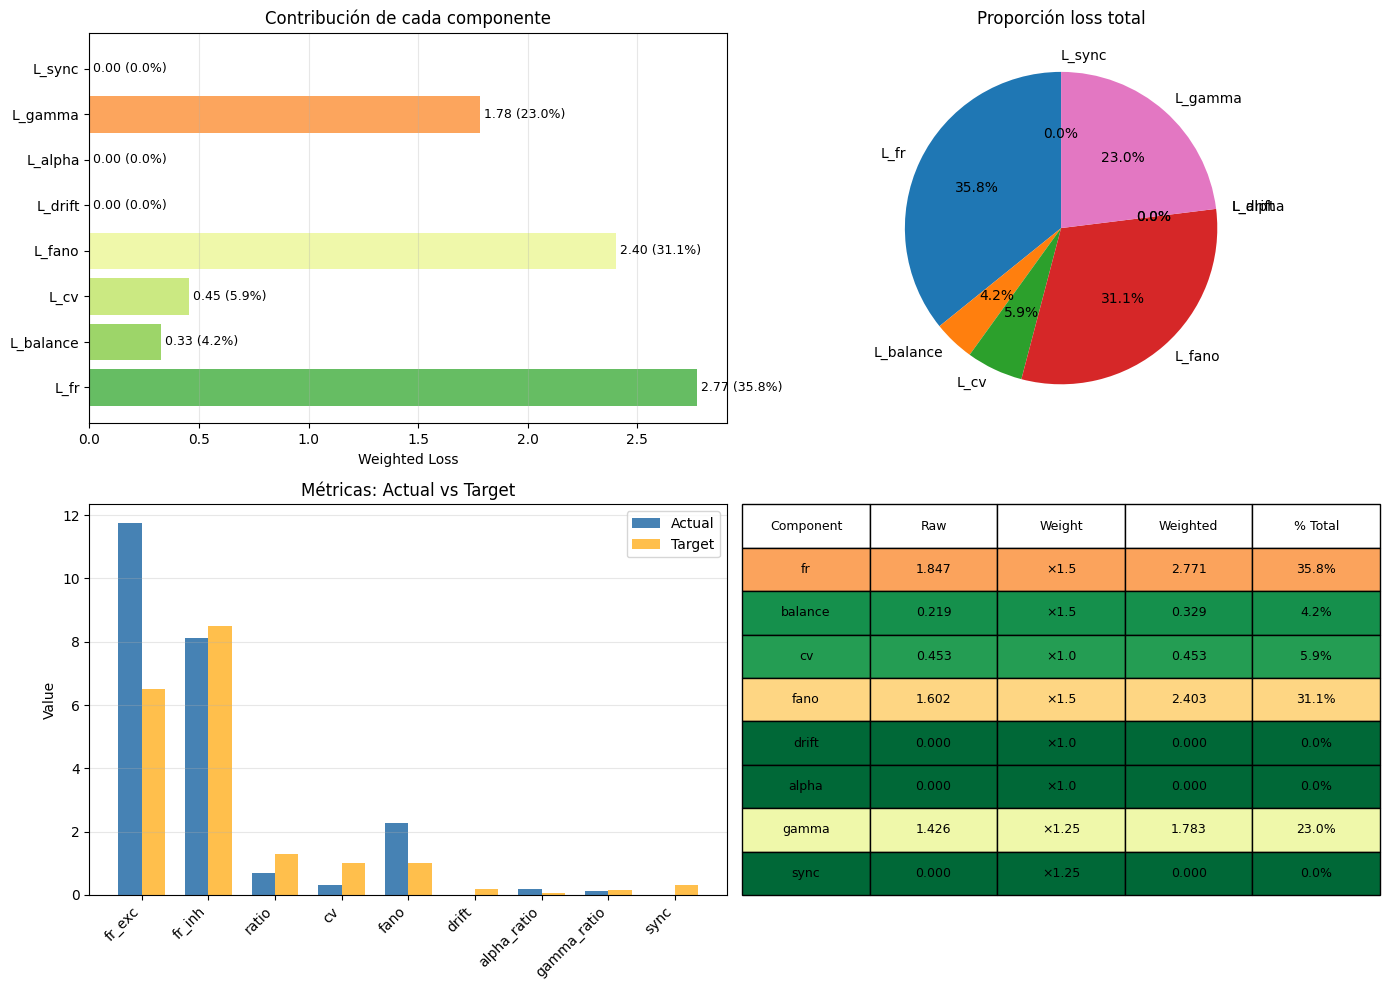


DESGLOSE COMPONENTES - MEJOR RESULTADO
Loss total: 7.784
Parámetros: rate=26.297, w_exc=0.490, w_inh=0.191

----------------------------------------------------------------------
Componente      Raw      Weight   Weighted   %Total   Status
----------------------------------------------------------------------
L_fr            1.847    ×1.5     2.771      35.8   % ⚠️  CRÍTICO
L_balance       0.219    ×1.5     0.329      4.2    % ✓ OK
L_cv            0.453    ×1.0     0.453      5.9    % ✓ OK
L_fano          1.602    ×1.5     2.403      31.1   % ⚠️  CRÍTICO
L_drift         0.000    ×1.0     0.000      0.0    % ✓ OK
L_alpha         0.000    ×1.0     0.000      0.0    % ✓ OK
L_gamma         1.426    ×1.2     1.783      23.0   % ⚠️  CRÍTICO
L_sync          0.000    ×1.2     0.000      0.0    % ✓ OK
----------------------------------------------------------------------
TOTAL                             7.740      100.0  %

MÉTRICAS RAW:
  fr_exc         : 11.748 (target=6.500, diff=80.7%)
  

In [35]:
# =============================================================================
# ANÁLISIS DE COMPONENTES DE PÉRDIDA
# =============================================================================

def analyze_loss_components_single(best_x, best_loss):
    """Analizar componentes del mejor resultado"""
    
    rate, w_exc, w_inh = best_x
    
    NETWORK_PARAMS = {
        'pop_A': {
            'Ne': 800, 'Ni': 200,
            'k_exc': 0.75, 'k_inh': 2.94,
            'noise_exc': w_exc, 'noise_inh': w_inh,
            'p_intra': 0.1, 'delay': 0.0, 'rate_hz': rate,
        }
    }
    SIM_CONFIG = {'dt_ms': 0.1, 'T_ms': 3000, 'warmup_ms': 500}
    
    results_sim, _, _ = run_iteration(NETWORK_PARAMS, SIM_CONFIG, trial=0)
    
    # Calcular cada componente
    spike_times = results_sim['A']['spike_times']
    spike_indices = results_sim['A']['spike_indices']
    valid = spike_times >= 500
    spike_times = spike_times[valid]
    spike_indices = spike_indices[valid]
    
    Ne, Ni = 800, 200
    exc_mask = spike_indices < Ne
    inh_mask = ~exc_mask
    
    time_span_s = 2.5
    eps = 1e-8
    fr_exc = np.sum(exc_mask) / (time_span_s * Ne + eps)
    fr_inh = np.sum(inh_mask) / (time_span_s * Ni + eps)
    
    L_fr = ((fr_exc - 5.0)/5.0)**2 + ((fr_inh - 7.0)/7.0)**2
    L_balance = ((fr_inh/(fr_exc+eps) - 1.3)/1.3)**2
    
    cv = compute_cv_isi(spike_times, spike_indices, Ne+Ni, 500)
    fano = compute_fano_factor(spike_times, 3000, 100, 500)
    L_cv = ((cv - 1.0)/1.0)**2 if np.isfinite(cv) else 100
    L_fano = ((fano - 1.0)/1.0)**2 if np.isfinite(fano) else 100
    
    # Drift
    mid_time = 500 + 1250
    mask_first = (spike_times < mid_time) & exc_mask
    mask_second = (spike_times >= mid_time) & exc_mask
    fr_first = np.sum(mask_first) / (1.25 * Ne + eps)
    fr_second = np.sum(mask_second) / (1.25 * Ne + eps)
    drift = abs(fr_first - fr_second) / ((fr_first + fr_second)/2 + eps)
    L_drift = (drift / 0.2)**2
    
    # PSD
    freqs, psd = compute_psd(spike_times, 3000, 500)
    alpha_mask = (freqs >= 8) & (freqs <= 12)
    gamma_mask = (freqs >= 40) & (freqs <= 80)
    total_mask = (freqs >= 0) & (freqs <= 100)
    
    alpha_power = np.trapz(psd[alpha_mask], freqs[alpha_mask])
    gamma_power = np.trapz(psd[gamma_mask], freqs[gamma_mask])
    total_power = np.trapz(psd[total_mask], freqs[total_mask]) + 1e-12
    
    alpha_ratio = alpha_power / total_power
    gamma_ratio = gamma_power / total_power
    
    L_alpha = (max(0, 0.15 - alpha_ratio))**2 / (0.07**2)
    L_gamma = (max(0, 0.30 - gamma_ratio))**2 / (0.15**2)
    
    sync = compute_sync_index(spike_times, spike_indices, 500)
    L_sync = max(0, sync - 0.3)**2 if np.isfinite(sync) else 1.0
    
    # Resumen
    components = {
        'L_fr': L_fr,
        'L_balance': L_balance,
        'L_cv': L_cv,
        'L_fano': L_fano,
        'L_drift': L_drift,
        'L_alpha': L_alpha,
        'L_gamma': L_gamma,
        'L_sync': L_sync
    }
    
    weights = {
        'L_fr': 1.5,
        'L_balance': 1.5,
        'L_cv': 1.0,
        'L_fano': 1.5,
        'L_drift': 1.0,
        'L_alpha': 1.0,
        'L_gamma': 1.25,
        'L_sync': 1.25
    }
    
            
    # Métricas raw
    metrics = {
        'fr_exc': fr_exc,
        'fr_inh': fr_inh,
        'ratio': fr_inh/(fr_exc+eps),
        'cv': cv,
        'fano': fano,
        'drift': drift,
        'alpha_ratio': alpha_ratio,
        'gamma_ratio': gamma_ratio,
        'sync': sync
    }
    
    return components, weights, metrics

# Analizar mejor resultado
components, weights, metrics = analyze_loss_components_single(best_x, best_loss)

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Contribución por componente
ax = axes[0, 0]
comp_names = list(components.keys())
weighted_vals = [components[k] * weights[k] for k in comp_names]
total = sum(weighted_vals)

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(comp_names)))
bars = ax.barh(comp_names, weighted_vals, color=colors)
ax.set_xlabel('Weighted Loss')
ax.set_title('Contribución de cada componente')
ax.grid(alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars, weighted_vals)):
    pct = val/total*100
    ax.text(val, i, f' {val:.2f} ({pct:.1f}%)', va='center', fontsize=9)

# 2. Pie chart contribución
ax = axes[0, 1]
ax.pie(weighted_vals, labels=comp_names, autopct='%1.1f%%', startangle=90)
ax.set_title('Proporción loss total')

# 3. Métricas vs targets
ax = axes[1, 0]
targets = {
    'fr_exc': 6.5,
    'fr_inh': 8.5,
    'ratio': 1.3,
    'cv': 1.0,
    'fano': 1.0,
    'drift': 0.2,
    'alpha_ratio': 0.07,
    'gamma_ratio': 0.15,
    'sync': 0.3
}

metric_names = list(metrics.keys())
actual = [metrics[k] for k in metric_names]
target = [targets[k] for k in metric_names]

x = np.arange(len(metric_names))
width = 0.35

bars1 = ax.bar(x - width/2, actual, width, label='Actual', color='steelblue')
bars2 = ax.bar(x + width/2, target, width, label='Target', color='orange', alpha=0.7)

ax.set_ylabel('Value')
ax.set_title('Métricas: Actual vs Target')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=45, ha='right')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# 4. Tabla resumen
ax = axes[1, 1]
ax.axis('off')

table_data = []
for k in comp_names:
    table_data.append([
        k.replace('L_', ''),
        f"{components[k]:.3f}",
        f"×{weights[k]}",
        f"{components[k]*weights[k]:.3f}",
        f"{components[k]*weights[k]/total*100:.1f}%"
    ])

table = ax.table(cellText=table_data,
                colLabels=['Component', 'Raw', 'Weight', 'Weighted', '% Total'],
                cellLoc='center',
                loc='center',
                bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Colorear filas por contribución
for i in range(len(comp_names)):
    pct = components[comp_names[i]]*weights[comp_names[i]]/total
    color = plt.cm.RdYlGn_r(pct * 2)  # Escalar para visualización
    for j in range(5):
        table[(i+1, j)].set_facecolor(color)

plt.tight_layout()
plt.savefig('optimization_results/best_loss_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen texto
print("\n" + "="*70)
print("DESGLOSE COMPONENTES - MEJOR RESULTADO")
print("="*70)
print(f"Loss total: {best_loss:.3f}")
print(f"Parámetros: rate={best_x[0]:.3f}, w_exc={best_x[1]:.3f}, w_inh={best_x[2]:.3f}")
print("\n" + "-"*70)
print(f"{'Componente':<15} {'Raw':<8} {'Weight':<8} {'Weighted':<10} {'%Total':<8} {'Status'}")
print("-"*70)

for k in comp_names:
    raw = components[k]
    w = weights[k]
    weighted = raw * w
    pct = weighted/total*100
    
    # Status basado en contribución
    if pct > 20:
        status = "⚠️  CRÍTICO"
    elif pct > 10:
        status = "⚡ Alto"
    else:
        status = "✓ OK"
    
    print(f"{k:<15} {raw:<8.3f} ×{w:<7.1f} {weighted:<10.3f} {pct:<7.1f}% {status}")

print("-"*70)
print(f"{'TOTAL':<15} {'':<8} {'':<8} {total:<10.3f} {100.0:<7.1f}%")
print("="*70)

print("\nMÉTRICAS RAW:")
for k, v in metrics.items():
    target_val = targets[k]
    diff = abs(v - target_val)
    pct_diff = diff/target_val*100
    print(f"  {k:<15}: {v:.3f} (target={target_val:.3f}, diff={pct_diff:.1f}%)")

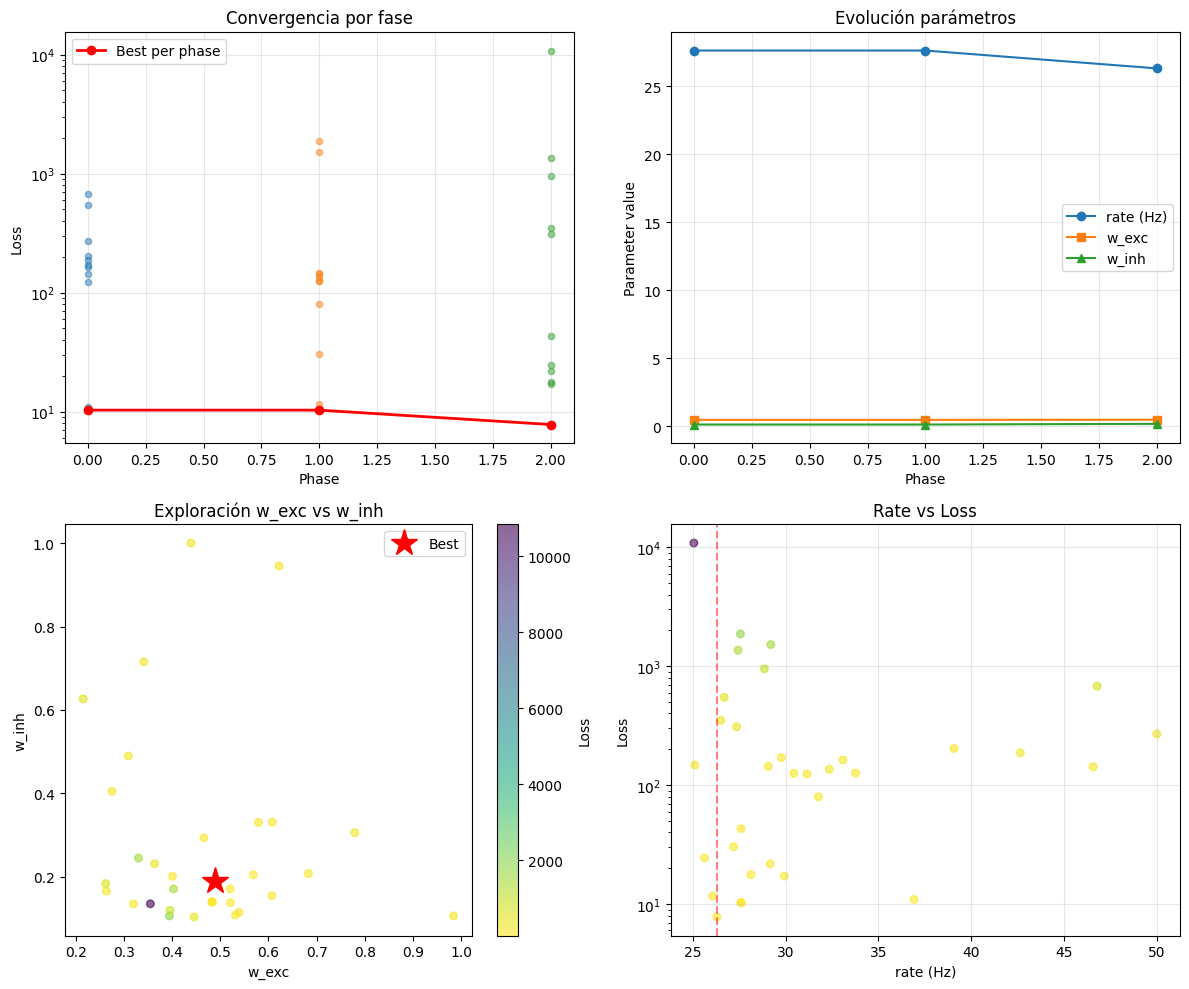

WARNING    /tmp/ipykernel_3496688/3871494898.py:76: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  print(f"Evaluaciones totales: {sum(len(r.func_vals) for r in results)}")
 [py.warnings]



RESUMEN OPTIMIZACIÓN
Mejor parámetros: rate=26.297, w_exc=0.490, w_inh=0.191
Mejor loss: 7.784

Fases ejecutadas: 3
Evaluaciones totales: 33
Loss mínima encontrada: 7.784
Mejora total: 10.286 → 7.784 (24.3%)


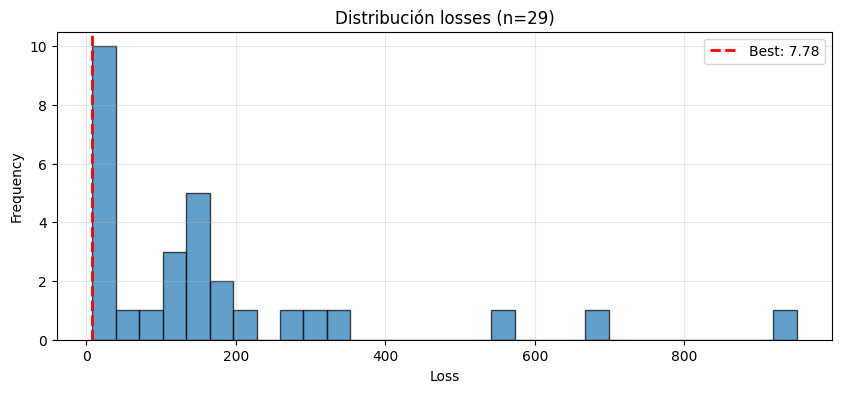


SENSIBILIDAD ESTIMADA
rate    : ρ=+0.134 (p=0.6779)
w_exc   : ρ=-0.113 (p=0.7269)
w_inh   : ρ=-0.198 (p=0.5383)


In [36]:
# =============================================================================
# ANÁLISIS POST-OPTIMIZACIÓN
# =============================================================================

def analyze_optimization_results(best_x, best_loss, results):
    """Analizar convergencia y calidad del óptimo"""
    
    # 1. Convergencia por fase
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Loss por fase
    ax = axes[0, 0]
    all_losses = []
    phase_labels = []
    for i, res in enumerate(results):
        losses = res.func_vals
        all_losses.extend(losses)
        phase_labels.extend([i]*len(losses))
        ax.scatter([i]*len(losses), losses, alpha=0.5, s=20)
    ax.plot([res.fun for res in results], 'r-o', linewidth=2, label='Best per phase')
    ax.set_xlabel('Phase')
    ax.set_ylabel('Loss')
    ax.set_yscale('log')
    ax.set_title('Convergencia por fase')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Parámetros óptimos por fase
    ax = axes[0, 1]
    rates = [res.x[0] for res in results]
    w_excs = [res.x[1] for res in results]
    w_inhs = [res.x[2] for res in results]
    ax.plot(rates, 'o-', label='rate (Hz)')
    ax.plot(w_excs, 's-', label='w_exc')
    ax.plot(w_inhs, '^-', label='w_inh')
    ax.set_xlabel('Phase')
    ax.set_ylabel('Parameter value')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_title('Evolución parámetros')
    
    # Exploración 2D: w_exc vs w_inh
    ax = axes[1, 0]
    all_x = np.array([x for res in results for x in res.x_iters])
    all_y = np.array([y for res in results for y in res.func_vals])
    scatter = ax.scatter(all_x[:, 1], all_x[:, 2], c=all_y, 
                        cmap='viridis_r', alpha=0.6, s=30)
    ax.plot(best_x[1], best_x[2], 'r*', markersize=20, label='Best')
    ax.set_xlabel('w_exc')
    ax.set_ylabel('w_inh')
    ax.set_title('Exploración w_exc vs w_inh')
    ax.legend()
    plt.colorbar(scatter, ax=ax, label='Loss')
    
    # Exploración: rate vs loss
    ax = axes[1, 1]
    ax.scatter(all_x[:, 0], all_y, alpha=0.6, s=30, c=all_y, cmap='viridis_r')
    ax.axvline(best_x[0], color='r', linestyle='--', alpha=0.5)
    ax.set_xlabel('rate (Hz)')
    ax.set_ylabel('Loss')
    ax.set_yscale('log')
    ax.set_title('Rate vs Loss')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('optimization_results/analysis_convergence.png', dpi=150)
    plt.show()
    
    # 2. Estadísticas finales
    print("\n" + "="*60)
    print("RESUMEN OPTIMIZACIÓN")
    print("="*60)
    print(f"Mejor parámetros: rate={best_x[0]:.3f}, w_exc={best_x[1]:.3f}, w_inh={best_x[2]:.3f}")
    print(f"Mejor loss: {best_loss:.3f}")
    print(f"\nFases ejecutadas: {len(results)}")
    print(f"Evaluaciones totales: {sum(len(r.func_vals) for r in results)}")
    print(f"Loss mínima encontrada: {min(r.fun for r in results):.3f}")
    print(f"Mejora total: {results[0].fun:.3f} → {best_loss:.3f} ({(1-best_loss/results[0].fun)*100:.1f}%)")
    
    # 3. Distribución de losses
    fig, ax = plt.subplots(figsize=(10, 4))
    valid_losses = [l for l in all_losses if l < 1000]
    if valid_losses:
        ax.hist(valid_losses, bins=30, alpha=0.7, edgecolor='k')
        ax.axvline(best_loss, color='r', linestyle='--', linewidth=2, label=f'Best: {best_loss:.2f}')
        ax.set_xlabel('Loss')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Distribución losses (n={len(valid_losses)})')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.savefig('optimization_results/loss_distribution.png', dpi=150)
        plt.show()
    
    # 4. Sensibilidad: ¿qué parámetros importan más?
    print("\n" + "="*60)
    print("SENSIBILIDAD ESTIMADA")
    print("="*60)
    valid_mask = np.array(all_y) < 100
    if np.sum(valid_mask) > 10:
        from scipy.stats import spearmanr
        for i, name in enumerate(['rate', 'w_exc', 'w_inh']):
            corr, pval = spearmanr(all_x[valid_mask, i], np.array(all_y)[valid_mask])
            print(f"{name:8s}: ρ={corr:+.3f} (p={pval:.4f})")

# Usar después de optimización
analyze_optimization_results(best_x, best_loss, results)

In [37]:
# Diagnóstico rápido
def diagnose_optimization(results):
    all_losses = [l for res in results for l in res.func_vals]
    
    print("DIAGNÓSTICO:")
    print(f"1. ¿Muchos fallos? {np.sum(np.array(all_losses) >= 1e5)} / {len(all_losses)}")
    print(f"2. ¿Converge? Std últimas 20: {np.std(all_losses[-20:]):.2f}")
    print(f"3. ¿Loss razonable? Min={min(all_losses):.2f}, Median={np.median(all_losses):.2f}")
    print(f"4. ¿Explora bien? Unique losses: {len(np.unique(all_losses))}")
    
    if min(all_losses) > 50:
        print("\n⚠️ PROBLEMA: Loss muy alta, revisar:")
        print("  - Targets demasiado estrictos")
        print("  - Pesos desequilibrados")
        print("  - Rangos de búsqueda incorrectos")

diagnose_optimization(results)

DIAGNÓSTICO:
1. ¿Muchos fallos? 0 / 33
2. ¿Converge? Std últimas 20: 2346.76
3. ¿Loss razonable? Min=7.78, Median=142.61
4. ¿Explora bien? Unique losses: 32


=== Resultado final adaptativo ===
Mejor x: [1.5124835379872539, 0.6125, 0.40625]
Mejor loss: 1.5827115435143204
Parámetros óptimos adaptativos: [1.5124835379872539, 0.6125, 0.40625]
Pérdida óptima adaptativa: 1.5827115435143204

In [38]:
[res['fun'] for res in results]

[np.float64(10.285984712873944),
 np.float64(10.285984712873944),
 np.float64(7.784472989601865)]

In [39]:
result = results[2]

In [40]:
# Extraer óptimo
best_params = result.x
best_rate, best_w_exc, best_w_inh = best_params
best_loss = result.fun

print(f"Óptimo: rate={best_rate:.2f} Hz, w_exc={best_w_exc:.3f}, w_inh={best_w_inh:.3f}")
print(f"Loss: {best_loss:.1f}")

# ⚠️ PROBLEMA: Loss=1e6 indica TODAS las sims fallaron
# Revisar func_vals
print(f"\nTodas las losses: {np.unique(result.func_vals)}")

# Si todas son 1e6 → debugging necesario
if np.all(result.func_vals >= 1000):
    print("❌ Todas las sims fallaron. Causas posibles:")
    print("  - FR fuera de [2,15] Hz (L_bounds)")
    print("  - Exception en simulate()")
    print("  - Rate muy bajo/alto")

Óptimo: rate=26.30 Hz, w_exc=0.490, w_inh=0.191
Loss: 7.8

Todas las losses: [7.78447299e+00 1.71740173e+01 1.77323729e+01 2.18205413e+01
 2.44379543e+01 4.30025884e+01 3.09480574e+02 3.50628721e+02
 9.50031435e+02 1.36232326e+03 1.08337114e+04]


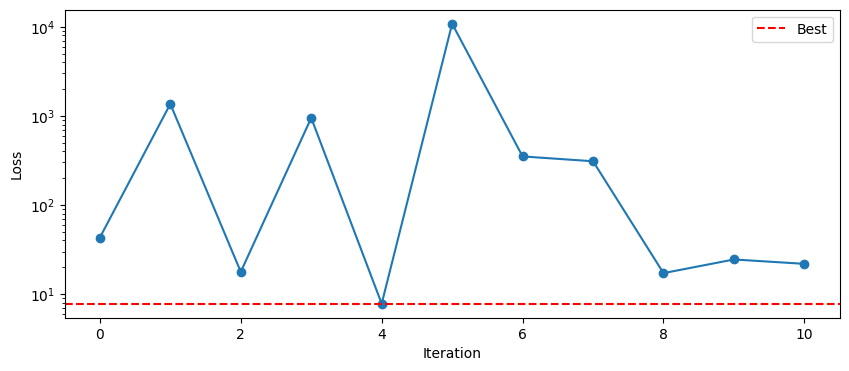

In [41]:
# Plot convergencia
losses = result.func_vals
plt.figure(figsize=(10,4))
plt.plot(losses, 'o-')
plt.axhline(best_loss, color='r', linestyle='--', label='Best')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.savefig('optimization_convergence.png')

In [50]:
# Simulation parameters
SIM_CONFIG = {
'dt_ms': 0.1,
'T_ms': 4000,
'warmup_ms': 500
}

rate=26.30
w_exc=0.490
w_inh=0.191

k_factor = 4.0

# Network parameters
NETWORK_PARAMS = {
    'pop_A': {
        'Ne': 800, 'Ni': 200,
        'k_exc': k_factor, 'k_inh': k_factor*3.9,
        'noise_exc': w_exc, 
        'noise_inh': w_inh,
        'p_intra': 0.1, 
        'delay': 0.0,
        'rate_hz':rate
    }
}

    
results, network, SIM_CONFIG = run_iteration(NETWORK_PARAMS, SIM_CONFIG, 0)

INFO     | __main__:run_iteration:13 - Simulation configured:
INFO     | __main__:run_iteration:14 -   Duration: 4000ms, dt: 0.1ms
SUCCESS  | src.two_populations.model:__init__:45 - Network initialized with seeds: {'trial': 1, 'fixed_seed_A': 99, 'fixed_seed_B': 101, 'fixed_seed_common': 100, 'variable_common_current': 204, 'variable_A_current': 204, 'variable_B_current': 207}
INFO     | src.two_populations.model:_create_stimulus2:308 - Creating Poisson for A with seed state: 200
INFO     | src.two_populations.model:_create_stimulus2:370 - PoissonGroup A: 100 sources @ 26.3Hz → 80000 exc + 20000 inh synapses
INFO     | src.two_populations.model:create_population2:285 - Population A (PoissonInput): 800E/200I, 79872+20190 syn
INFO     | __main__:run_iteration:37 - 
INFO     | __main__:run_iteration:38 - SIMULATION COMPLETED
INFO     | __main__:run_iteration:39 - ==================================================
INFO     | __main__:run_iteration:40 - Population A: 67800 spikes
INFO     |

INFO     | src.two_populations.metrics:analyze_simulation_results:670 - 
=== Baseline (lfp) ===
INFO     | src.two_populations.metrics:analyze_simulation_results:677 - Single population analysis
INFO     | src.two_populations.metrics:analyze_simulation_results:678 - Timescale A: 0.1ms
INFO     | src.two_populations.metrics:calculate_synchrony_metrics:751 -     DEBUG: CV_individual=0.346, CV_population=0.730
INFO     | src.two_populations.metrics:print_network_statistics_table:814 - 
INFO     | src.two_populations.metrics:print_network_statistics_table:816 - ESTADÍSTICAS DE RED - Población A (Post-warmup 500ms)
INFO     | src.two_populations.metrics:print_network_statistics_table:817 - ================================================================================
INFO     | src.two_populations.metrics:print_network_statistics_table:819 - Métrica                   Población A               Población B              
INFO     | src.two_populations.metrics:print_network_statistics_table:8

baseline: 500 monitored, 400 exc
  Plotting: [np.int64(174), np.int64(501), np.int64(329), np.int64(801), np.int64(926), np.int64(970)]


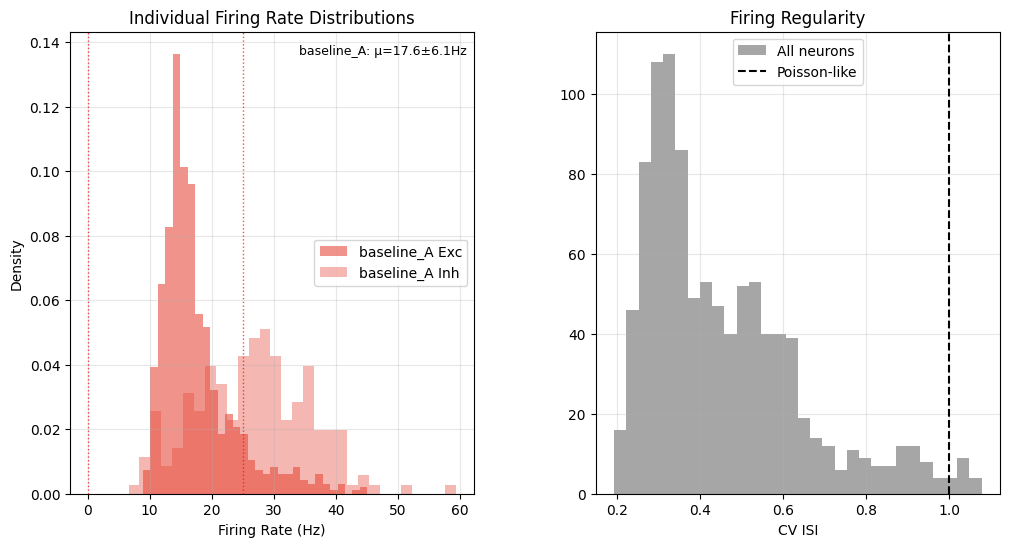

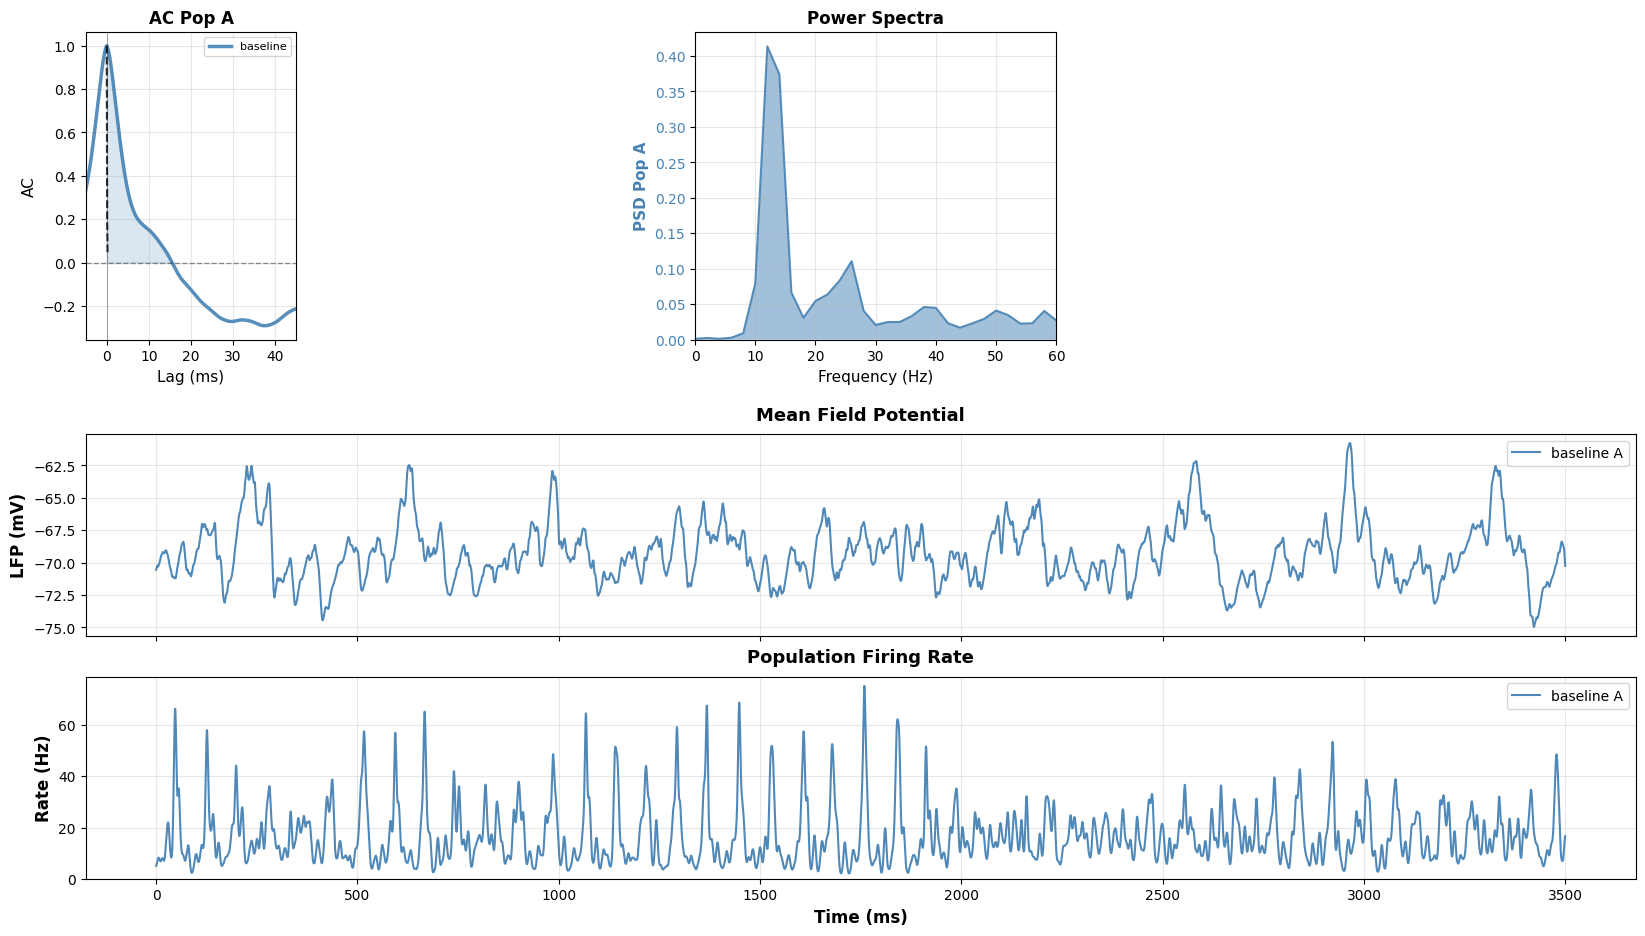

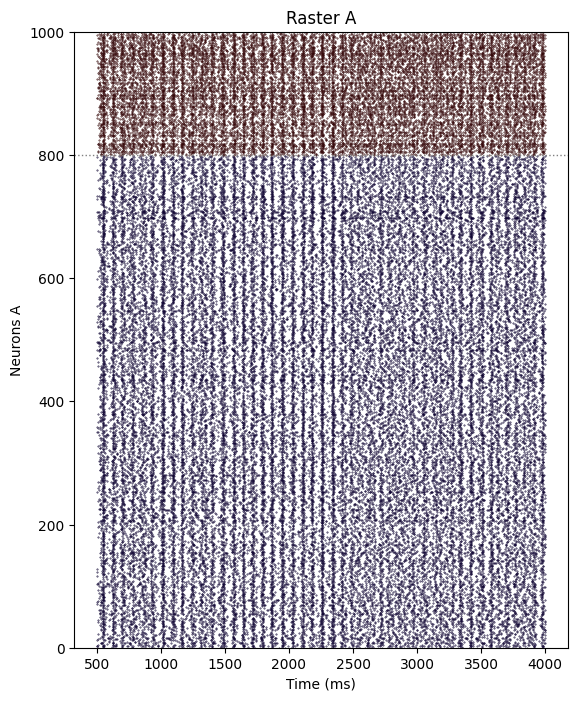

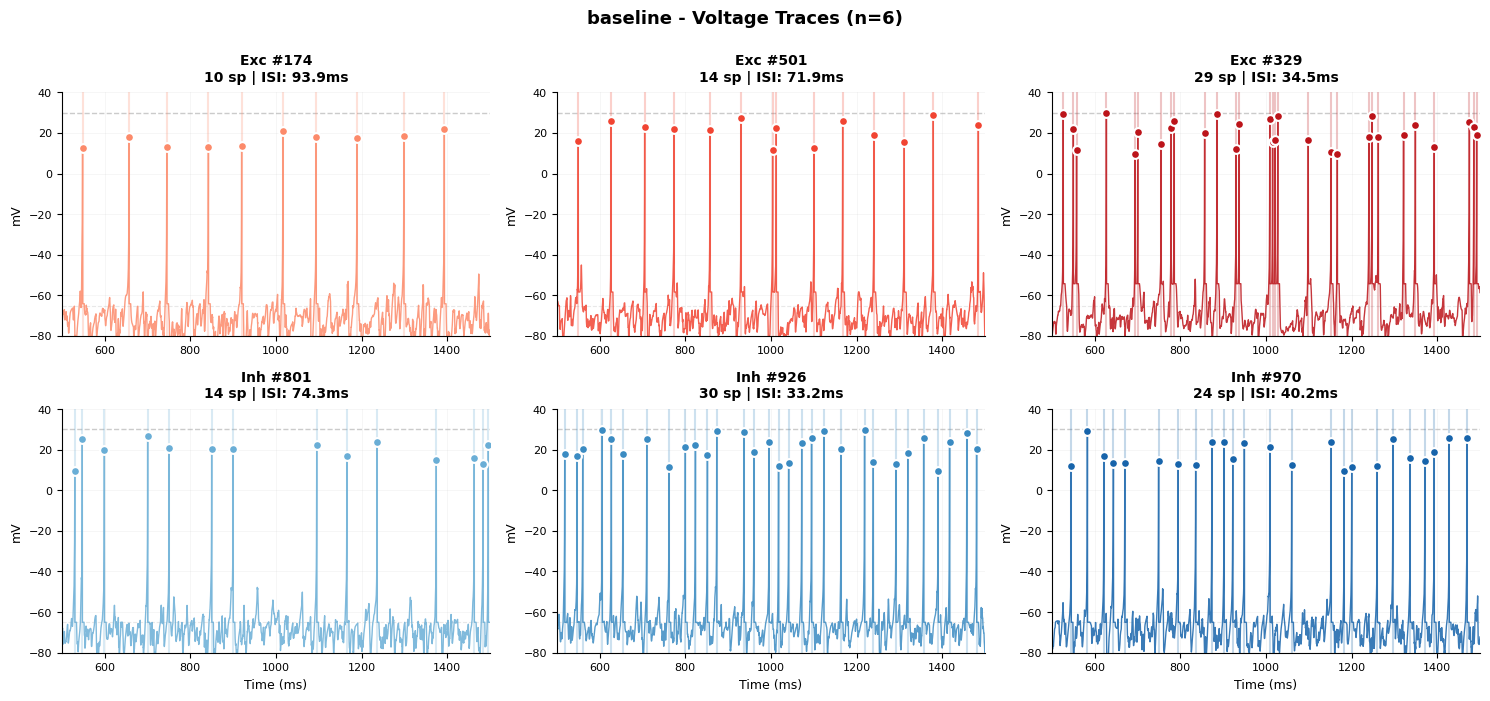

In [51]:
from src.two_populations.plots.dashboard_plots import plot_population_dashboard
from src.two_populations.plots.basic_plots import plot_raster_results, plot_voltage_traces
# =============================================================================
# ANALYSIS WITH VALIDATION
# =============================================================================
from src.two_populations.helpers.validator import (
    add_validation_to_analysis, 
    plot_population_validation_dashboard, 
    print_validation_summary
)
from src.two_populations.metrics import analyze_simulation_results

# Analyze connectivity
results_dict = {
    'baseline': analyze_simulation_results(
        results['A']['spike_monitor'], 
        None, 
        1000, "Baseline", 
        warmup=SIM_CONFIG['warmup_ms'],
        state_monitors={'A': network.monitors['A']},
        signal_mode = 'lfp',
        T_total=SIM_CONFIG['T_ms'] # firing_rate
    )
}

# Add validation metrics
validation_results = add_validation_to_analysis(results_dict)

# Network statistics table
print_network_statistics_table(
    results, network, 
    N_exc=800, N_inh=200, 
    T_total=SIM_CONFIG['T_ms'], 
    warmup=SIM_CONFIG['warmup_ms']
)

# Dashboards
fig_val = plot_population_validation_dashboard(validation_results)
print_validation_summary(validation_results)

fig_pop = plot_population_dashboard(results_dict)
plot_raster_results(results)
plot_voltage_traces(results_dict, results, (500,1500), 3, 3, 3)
plt.show()